In [1]:
import numpy as np
anil = np.array([0.45, 0.51, 0.04, 0])
enes = np.array([0.49, 0.48, 0.025, 0.005])
bilge = np.array([0.43, 0.54, 0.02, 0.01])

gercek = np.array([0.4950, 0.4489, 0.0517, 0.0044])

print(f'anil {np.sum(np.abs(anil - gercek)):.2f}')
print(f'enes {np.sum(np.abs(enes - gercek)):.2f}')
print(f'bilge {np.sum(np.abs(bilge - gercek)):.2f}')

anil 0.12
enes 0.06
bilge 0.19


In [225]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.numpy.arange(10)

Array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [2]:
import dadi
import sys
import demes
import moments
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..")
sys.path.append("../slurm_performance_tests")

In [3]:
from Timing_util import total_variation

In [5]:
dadi.cuda_enabled(True)

creating CUBLAS context to get version number

True

In [6]:
demo2 = demes.load('timing_tests_yaml/2_pop_mig.yaml')
demo3 = demes.load('timing_tests_yaml/3_pop_mig.yaml')

In [8]:
def get_esfs_dadi(demo, sampled_demes, sample_sizes, pts):
    esfs = dadi.Spectrum.from_demes(
        demo, sampled_demes=sampled_demes, sample_sizes=sample_sizes, pts=pts
    )
    return esfs * 4 * demo.demes[0].epochs[0].start_size

def get_esfs_moments(demo, sampled_demes, sample_sizes):
    esfs = moments.Spectrum.from_demes(
        demo, sampled_demes=sampled_demes, sample_sizes=sample_sizes
    )
    return esfs * 4 * demo.demes[0].epochs[0].start_size

In [ ]:
PTS = [100, 150, 200, 300, 600]
TVs = {}

for ss in [5, 20]:
    for ndemes in [2, 3]:
        demo = demes.load(f'timing_tests_yaml/{ndemes}_pop_mig.yaml')
        sampled_demes = demo.metadata['sampled_demes']
        sample_sizes = len(sampled_demes) * [ss]
        
        mesfs = get_esfs_moments(demo, sampled_demes, sample_sizes)
        vecm = np.array(mesfs/mesfs.sum()).flatten()[1:-1]
        
        TV = []
        for pts in PTS:
            desfs = get_esfs_dadi(demo, sampled_demes, sample_sizes, pts)
            vecd = np.array(desfs/desfs.sum()).flatten()[1:-1]

            tv = total_variation(vecm, vecd)
            TV.append(tv)
        
        TVs[ss, ndemes] = TV

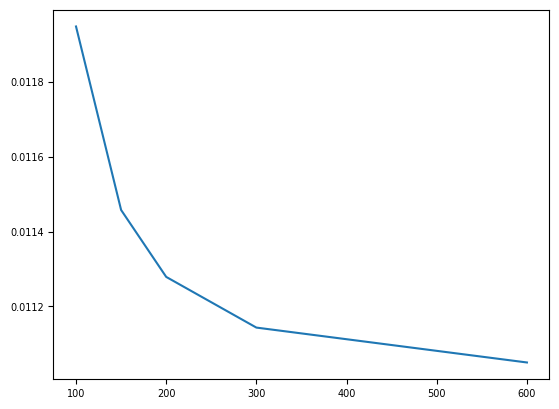

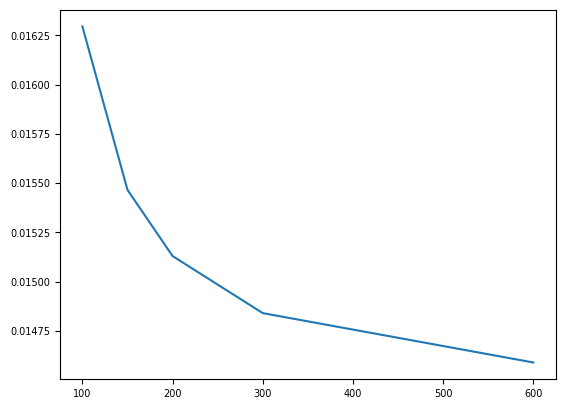

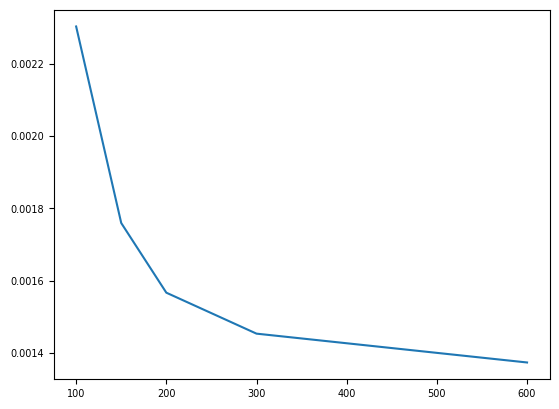

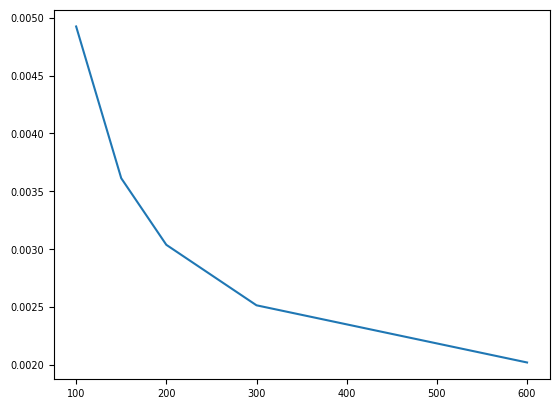

In [107]:
for ss in [5, 20]:
    for ndemes in [2, 3]:
        plt.plot(PTS, TVs[ss, ndemes])
        plt.show()

0.03967054553246766

In [ ]:
plt.plot()

In [5]:
demo = demes.load('timing_tests_yaml/')

In [10]:
def get_demo_3():

    size = 5000
    t = 5000

    D = demes.Builder()
    D.add_deme("ANC", epochs=[dict(start_size=size, end_time=t)])
    D.add_deme("AB", epochs=[dict(start_size=size, end_time=t-1)], ancestors=["ANC"])
    D.add_deme("A", epochs=[dict(start_size=size)], ancestors=["AB"])
    D.add_deme("B", epochs=[dict(start_size=size)], ancestors=["AB"])
    D.add_deme("C", epochs=[dict(start_size=size)], ancestors=["ANC"])

    demo = D.resolve()
    return demo

In [11]:
demo = get_demo_3()

In [12]:
esfs = dadi.Spectrum.from_demes(demo, sampled_demes=['A', 'B', 'C'], sample_sizes=3 * [4], pts=25)

In [6]:
sample_sizes = [4, 5, 6, 7, 5]
sampled_demes = demo.metadata['sampled_demes']
n = 5

KeyError: 'sampled_demes'

In [25]:

pts = [int(n * 1.1) + 2, int(n * 1.2) + 4, int(n * 1.3) + 6]

In [52]:
dadi.RAM_to_pts(1, 5)

32

In [38]:
esfs = dadi.Spectrum.from_demes(demo, sampled_demes=sampled_demes, sample_sizes=sample_sizes, pts=25)

KeyboardInterrupt: 

In [ ]:
mesfs = moments.Spectrum.from_demes(demo, sampled_demes=sampled_demes, sample_sizes=sample_sizes)

In [ ]:
esfs/mesfs

In [14]:
esfs

Spectrum([[[[[-- 0.5594821374331285 0.12645331029010998 0.04905490751203062
     0.014781216332524015 0.0030136624486601787]
    [0.6074206357012697 0.13822920258084082 0.07954806866965289
     0.03852264272904543 0.01525195081360086 0.0046561157461845835]
    [0.13767089046523573 0.07733888918724027 0.04907626637265636
     0.027934184416658153 0.01406527824825566 0.005748442953597041]
    [0.04901717770449218 0.03408184592291848 0.02540243565581969
     0.017880692998678373 0.011511351530042187 0.0061963773657444255]
    [0.01305427006324112 0.011336951694269255 0.011009152600921772
     0.010031409941519076 0.008260581602839467 0.005959885172512653]
    [0.0018907519071388948 0.0027109611937008154 0.0036695591814784583
     0.004357259629163125 0.004656183079112097 0.005290450022278434]]

   [[0.9247046272554087 0.004279876064914846 0.002467059471060167
     0.0010152164049172007 0.00030155186439312105
     6.594407789550972e-05]
    [0.0058352348168837845 0.0031205334269368036 0.00

In [3]:
# import os
# import sys
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"

In [4]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%alias_magic t timeit
%load_ext memory_profiler

Created `%t` as an alias for `%timeit`.
Created `%%t` as an alias for `%%timeit`.


In [5]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0."
import jax
jax.config.update('jax_platform_name', 'cpu')

In [6]:
import operator
from functools import partial, reduce

import jax
import demes
import jax.numpy as jnp
import numpy as np
import scipy.sparse.linalg
from jax import jacfwd, jacrev, jit
from jax.experimental.sparse import BCOO
from jax.experimental.sparse import empty as sp_empty
from functools import lru_cache
import msprime as msp
from copy import deepcopy
import numdifftools as nd
from time import time

import matplotlib.pyplot as plt

import pickle
import moments
import tskit

from ast import literal_eval

import sys
import demes, demesdraw
sys.path.append("..")
sys.path.append("../slurm_performance_tests")

In [7]:
from momi3.utils import moran_transition, moran_eigensystem, one_hot, RateCPS, rate_matrix
from momi3.math_functions import log_hypergeom

onehot = lambda n, b: jnp.array(one_hot(n, b))

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)

In [8]:
def lift(l, rate):
    n = len(l) - 1
    d, Q = moran_eigensystem(n)
    M = moran_transition(rate, d, Q)
    return M @ l   

def lemma_Split2(l1, l2):
    nw1 = l1.shape[0] - 1
    nw2 = l2.shape[0] - 1
    nv = nw1 + nw2

    x1, x2, xv = jnp.ogrid[: nw1 + 1, : nw2 + 1, : nv + 1]

    Hyp = jnp.exp(log_hypergeom(n=nw1, k=x1, M=nv, N=xv)) * (xv == x1 + x2)

    #return jnp.einsum(Hyp, l1, l2)
    return jnp.tensordot(jnp.tensordot(Hyp, l1, axes=(0, 0)), l2, axes=(0, 0))

In [9]:
Ne1 = 10.
Ne2 = 11.
Ne3 = 12.
Ne4 = 13.
t1 = 4.
t2 = 10.


n1 = 11
n2 = 8
n3 = 5

b1 = 2
b2 = 1
b3 = 0

l1 = onehot(n1 + 1, b1)
l2 = onehot(n2 + 1, b2)
l3 = onehot(n3 + 1, b3)

In [10]:
def der_split_tau(tau, Ne1, Ne2):
    return (Ne1 + Ne2) / Ne1 / Ne2

def der_split_Ne(tau, Ne):
    return - tau / Ne ** 2

Pop size
$$
Q \frac{\partial}{\partial\eta}R(\eta, \tau)
$$

Constant size
$$
-Q \frac{\tau}{\eta^2} 
$$

Time
$$
\frac{\partial}{\partial\tau}R(\eta_1, \tau) \frac{\partial}{\partial\tau}R(\eta_2, \tau) Q_1e^{Q_1R(\eta_1, \tau)} Q_2e^{Q_2R(\eta_2, \tau)}
$$

In [11]:
def GradientsDoGrowonTrees(params, p1, p2, p3, pi, Q):
    b1, b2, b3, b4 = params
    
    # branch lengths:
    # b1 = 1
    # b2 = 1.
    # b3 = 0.5
    # q = 0.1

    P1 = jax.scipy.linalg.expm(Q * b1)
    P2 = jax.scipy.linalg.expm(Q * b2)
    P1p1 = P1 @ p1
    P2p2 = P2 @ p2  
    p4 = P1p1 * P2p2

    P3 = jax.scipy.linalg.expm(Q * b3)
    P4 = jax.scipy.linalg.expm(Q * b4)
    P3p3 = P3 @ p3
    P4p4 = P4 @ p4
    p5 = P4p4 * P3p3  
    
    PY = pi @ p5
    
    q4 = P4.T @ (pi * P3p3)
    q3 = P3.T @ (pi * P4p4)
    q2 = P2.T @ (q4 * P1p1)
    q1 = P1.T @ (q4 * P2p2)
    
    return p1, p2, p3, p4, p5, P1, P2, P3, P4, PY, q4, q3, q2, q1

In [12]:
# Rate matrix:
Q = np.array(
    [
        [-2, 1, 1], 
        [1, -2, 1],
        [1, 1, -2]
    ]
)

# Initial states:
p1 = np.array([1, 0, 0]) # 1 has the state 0
p2 = np.array([0, 1, 0]) # 2 has the state 1
p3 = np.array([0, 0, 1]) # 3 has the state 2

params = jnp.array([1., 1., 2., 3.])
pi = jnp.array([0.2, 0.2, 0.6])

In [13]:
p1, p2, p3, p4, p5, P1, P2, P3, P4, PY, q4, q3, q2, q1 = GradientsDoGrowonTrees(params, p1, p2, p3, pi, Q)

In [14]:
np.isclose(p4.T @ q4, PY)

True

In [15]:
np.isclose(p3.T @ q3, PY)

True

In [16]:
np.isclose(p2.T @ q2, PY)

True

In [17]:
np.isclose(p1.T @ q1, PY)

True

In [18]:
q1 @ Q @ p1

Array(0.00027622, dtype=float32)

In [19]:
q2 @ Q @ p2

Array(0.00027621, dtype=float32)

In [20]:
q3 @ Q @ p3

Array(-0.00021979, dtype=float32)

In [21]:
q4 @ Q @ p4

Array(5.2393625e-07, dtype=float32)

In [22]:
def lik(params, p1, p2, p3, pi, Q):
    p1, p2, p3, p4, p5, P1, P2, P3, P4, PY, q4, q3, q2, q1 = GradientsDoGrowonTrees(params, p1, p2, p3, pi, Q)
    return PY

In [23]:
jax.grad(lik)(params, p1, p2, p3, pi, Q)

Array([ 2.7620979e-04,  2.7620979e-04, -2.1978468e-04,  5.1967800e-07],      dtype=float32)

$$
\begin{split}
\frac{\partial}{\partial b_4} P(Y) &= q_4'Q p_4 / P(Y)\\
&= (P_4'[q_5 * (P_3p_3)])'Qp_4/P(Y)\\
&= e^{Qb_4}[\pi * e^{Qb_3} \ell_3]' Q e^{Qb_1} * \ell_1 *e^{Qb_2} * \ell_2  / P(Y)
\end{split}
$$

Post order
$$
\begin{split}
\frac{\partial}{\partial b_4} P(Y) &=  \pi_5 [[P_4*[P_1 \ell_1 * P_2 \ell_2]] * P_3 \ell_3]
\end{split}
$$

In [24]:
import demes

size = 10.
t = 10.
tp = 5.
p = 0.1

b = demes.Builder()
b.add_deme("AB", epochs=[dict(start_size=size, end_time=t)])
b.add_deme("A", epochs=[dict(start_size=size)], ancestors=["AB"])
b.add_deme("B", epochs=[dict(start_size=size)], ancestors=["AB"])
b.add_pulse(sources=["A"], dest="B", time=tp, proportions=[p])
demo = b.resolve()

In [25]:
from momi3.event_tree import ETBuilder

In [26]:
Tree = ETBuilder(demo, {'A':5, 'B':3})._T

In [27]:
import networkx as nx

In [28]:
sys.path.append('../../')

In [29]:
from momi_main.momi3.momi3.Events import Events

In [30]:
ET = Events(b)
ET._construct_events()

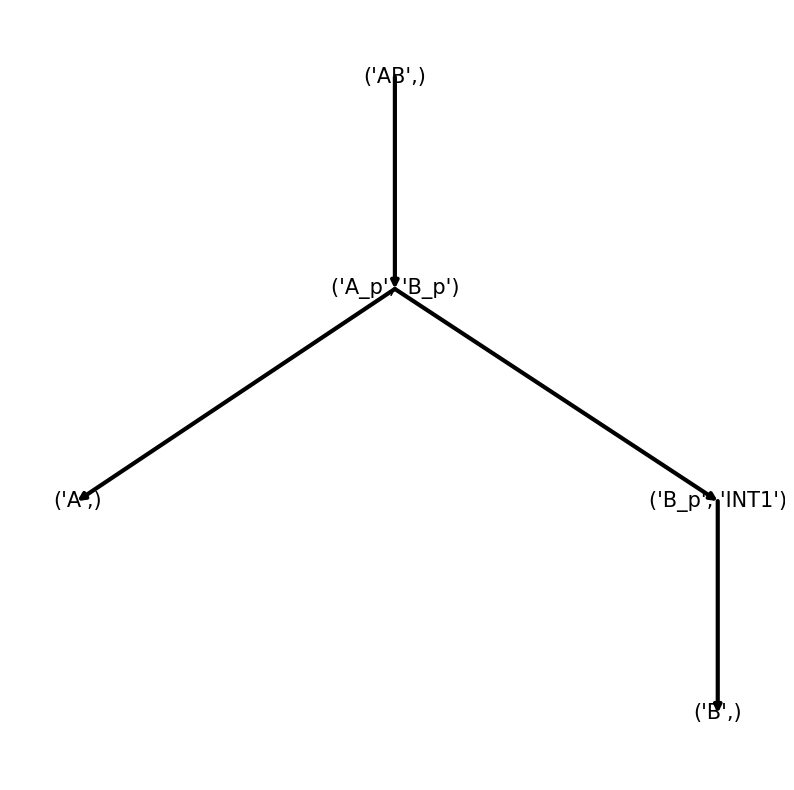

In [31]:
ET.draw_event_tree()

In [384]:
term1 = np.random.randn(2,3,4)
term2 = np.random.randn(5,3,7)

Z = jnp.einsum('xaz,tav->xztva', term1, term2)

In [391]:
term1 = np.random.randn(3,3,3,3)

In [398]:
X = jnp.diagonal(term1, axis1=1, axis2=2)

In [ ]:
Q = np.array(
    [
        [-3, 2, 1], 
        [2, -3, 1],
        [1, 2, -3]
    ]
)

In [570]:
X = jnp.kron(P1, P2)

(3, 3, 3)

In [573]:
jnp.kron(X, p).shape

(3, 27, 27)

In [566]:
P1@P2@P3

Array([[0.350841  , 0.39977878, 0.24938032],
       [0.35028785, 0.40033185, 0.24938032],
       [0.3483622 , 0.39977878, 0.25185907]], dtype=float32)

In [567]:
jax.scipy.linalg.expm(3 * Q * b1)

Array([[0.35084102, 0.39977878, 0.24938034],
       [0.3502879 , 0.40033185, 0.24938032],
       [0.3483622 , 0.39977875, 0.25185904]], dtype=float32)

In [689]:
np.random.seed(108)

b1 = 0.5
b2 = 0.2
b3 = 0.3

P1 = jax.scipy.linalg.expm(Q * b1)
P2 = jax.scipy.linalg.expm(Q * b2)
P3 = jax.scipy.linalg.expm(Q * b3)

p = np.random.randn(3)


In [690]:
#p_grad = jnp.einsum('ab,cd,ef,bdf', P1, Q@P2, P3, p)

In [691]:
def f(b):
    P1 = jax.scipy.linalg.expm(Q * b)
    P2 = jax.scipy.linalg.expm(Q * b)
    P3 = jax.scipy.linalg.expm(Q * b)
    p_lift = jnp.einsum('ax,bx,cx,x', P1, P2, P3, p)
    return p_lift

In [692]:
b = 0.5
X = jax.jacfwd(f)(b)

In [693]:
X.shape

(3, 3, 3)

In [694]:
P1 = P2 = P3 = jax.scipy.linalg.expm(Q * b)

In [698]:
t1 = jnp.einsum('ax,bx,cx,x', Q@P1, P2, P3, p)

In [699]:
A = jnp.einsum('abc->abc', t1) + jnp.einsum('abc->bac', t1) + jnp.einsum('abc->cab', t1)

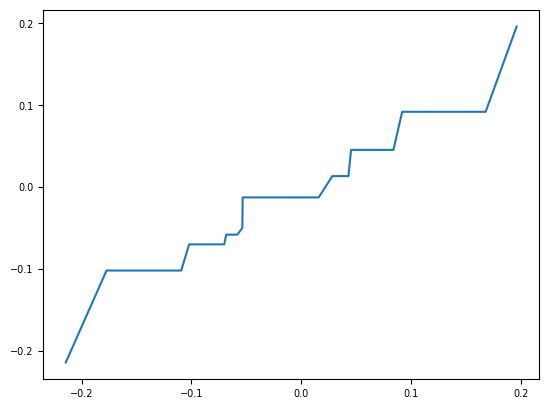

In [700]:
plt.plot(np.sort(A.flatten()), np.sort(X.flatten()))

In [535]:
np.sort(A.flatten())

array([-0.2419295 , -0.22582117, -0.21789032, -0.21022874, -0.18038528,
       -0.17576715, -0.16638288, -0.16465417, -0.16450894, -0.16233249,
       -0.16200526, -0.15317938, -0.1503146 , -0.1451824 , -0.13280909,
       -0.13259742, -0.1314087 , -0.12998924, -0.12667197, -0.12203951,
       -0.12093879, -0.11547521, -0.10783499, -0.1055878 , -0.10390394,
       -0.1030572 , -0.10225748, -0.10085249, -0.09734368, -0.09724526,
       -0.09447658, -0.09076034, -0.09032495, -0.08418782, -0.08340465,
       -0.08120977, -0.07981983, -0.07930774, -0.07746552, -0.07524684,
       -0.07475453, -0.07310624, -0.07140734, -0.07115066, -0.06866841,
       -0.06698449, -0.06671567, -0.06534152, -0.06456697, -0.06411998,
       -0.06372683, -0.06270655, -0.06229195, -0.06180847, -0.0610377 ,
       -0.05792367, -0.05775684, -0.05643527, -0.0556663 , -0.05483804,
       -0.05456358, -0.0530277 , -0.05278672, -0.05226849, -0.05173538,
       -0.05069064, -0.05064774, -0.04927887, -0.04918134, -0.04

In [524]:
jnp.isclose(A, X, rtol=0.1)

Array([[[[[ True,  True,  True],
          [ True,  True,  True],
          [ True,  True,  True]],

         [[False, False, False],
          [False, False, False],
          [False, False, False]],

         [[False, False, False],
          [False, False, False],
          [False, False, False]]],


        [[[ True,  True,  True],
          [ True,  True,  True],
          [ True,  True,  True]],

         [[False, False,  True],
          [False, False, False],
          [False, False, False]],

         [[False, False, False],
          [False, False, False],
          [False, False, False]]],


        [[[ True,  True,  True],
          [ True,  True,  True],
          [ True,  True,  True]],

         [[False, False,  True],
          [False, False, False],
          [False, False, False]],

         [[False, False, False],
          [False, False, False],
          [False, False, False]]]],



       [[[[False, False, False],
          [False, False, False],
          [False,

In [413]:
term1 = np.random.randn(3,3,3,3)

terma = term1.reshape(3,3,3,1,3)
termb = term1.reshape(3,3,3,3,1)

p = 0.1
(p * terma + (1-p) * termb)

(3, 3, 3, 3, 3)

In [ ]:
jnp.einsum('xaz,tav->xztva', term1, term2)

In [673]:
terma = term1.reshape(3,3,3,1,3)
termb = term1.reshape(3,3,3,3,1)

In [674]:
def f(p):
    return p * terma + (1-p) * termb
    

In [678]:
def get_q4(b3):
    P4 = jax.scipy.linalg.expm(Q * b3)
    return jnp.einsum('c,ca,cb', pi, P4, P4)

dget_q4 = jax.jacobian(get_q4)
dq4 = dget_q4(b3)

ValueError: Einstein sum subscript 'c' does not contain the correct number of indices for operand 0.

In [606]:
import scipy
import numpy as np
import jax.numpy as jnp
import jax

# Assume three-state character with 2 species with one horizontal gene transfer

def lik(params, P1, P2, pi, Q):
    b1, b2, b3, q = params
    
    # branch lengths:
    # b1 = 1
    # b2 = 1.
    # b3 = 0.5
    # q = 0.1

    # event1: Lift
    P1 = jax.scipy.linalg.expm(Q * b1)
    P2 = jax.scipy.linalg.expm(Q * b2)
    P1p1 = P1 @ p1
    P2p2 = P2 @ p2
    
    d1 = Q
    d2 = Q

    # event2: Admixture  
    p3 = P1p1[:, None] * (1 - q) + P1p1[None, :] * q
    
    dq = -P1p1[:, None] + P1p1[None, :]
    dq = dq / p3

    # event3: Merge
    p4 = p3 * P2p2[None,  :]
    p4x = jnp.einsum('ab,b->ab', p3, P2p2)
    
    # # event4: Diag merge
    P4 = jax.scipy.linalg.expm(Q * b3)
    #P4p4 = P4 @ (P4 @ p4).T
    P4p4 = P4 @ p4.T @ P4.T
    p5 = jnp.diag(P4p4)
      
    q5 = pi
    #q4 = (q5[None, :] @ P4).T @ (q5[None, :] @ P4)
    q4 = jnp.einsum('c,ca,cb', pi, P4, P4)
    q3 = q4 * P2p2
    q2 = P2.T @ (q4 * p3)
    q1 = P1.T @ (q3)
    
    
    def get_q4(b3):
        P4 = jax.scipy.linalg.expm(Q * b3)
        return jnp.einsum('c,ca,cb', pi, P4, P4)
    dget_q4 = jax.jacobian(get_q4)
    dq4 = dget_q4(b3)
    dq4 = dq4 / q4
    
    
    py = p5 @ pi
    
    return py, q4, p4, q3, p3, q2, p2, q1, p1, dq, d1, d2, dq4#  , d3, dp3

In [610]:
# Rate matrix:
Q = np.array(
    [
        [-3, 2, 1], 
        [2, -3, 1],
        [1, 2, -3]
    ]
)

# Initial states:
P1 = np.array([1, 0, 0]) # A has the state 0
P2 = np.array([0, 1, 0]) # B has the state 1

params = jnp.array([1., 1., 0.5, 0.1])

pi = jnp.array([0.3, 0.4, 0.3])

PY, q4, p4, q3, p3, q2, p2, q1, p1, dq, d1, d2, dq4 = lik(params, P1, P2, pi, Q) 

In [701]:
qi = np.random.rand(3,3)

In [788]:
import jax
import jax.numpy as jnp

def get_q4_loop(b3, qi, Q):
    P4 = jax.scipy.linalg.expm(Q * b3)
    A = B = C = P4
    # Dimensions of the arrays
    m_dim = A.shape[0]
    i_dim = B.shape[1]
    j_dim = A.shape[1]
    k_dim = A.shape[1]
    l_dim = A.shape[1]

    # Resulting array
    result = np.zeros((i_dim, j_dim, m_dim, i_dim))

    # For loop equivalent of the einsum expression
    for i in range(i_dim):
        for j in range(j_dim):
            for k in range(j_dim):
                for l in range(m_dim):
                    result[i, j, k, l] = 0
                    for m in range(m_dim):
                        result[i, j, k, l] += qi[m, i] * A[m, j] * B[m, k] * C[m, l]


    return result

In [789]:
def get_q4(b3, qi, Q):
    P4 = jax.scipy.linalg.expm(Q * b3)
    return jnp.einsum('mi,mj,mk,ml->ijkl', qi, P4, P4, P4)

In [791]:
X = get_q4(b3, qi, Q).flatten()
Y = get_q4_loop(b3, qi, Q).flatten()

In [792]:
np.sort(X)/np.sort(Y)

array([1.        , 1.00000006, 1.00000006, 1.00000006, 1.00000006,
       1.        , 1.        , 1.        , 1.00000008, 1.00000008,
       1.00000006, 1.00000006, 1.00000006, 1.00000006, 1.00000006,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.00000006, 1.        , 1.        , 1.        , 1.00000011,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.00000008, 1.00000008, 1.        , 1.        ,
       1.        , 1.00000007, 1.00000007, 1.00000007, 1.00000007,
       1.        , 1.        , 1.        , 1.00000006, 1.00000006,
       1.        , 1.00000006, 1.        , 1.00000006, 1.00000006,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       0.99999989, 0.99999989, 1.        , 1.        , 1.        ,
       1.        , 1.0000001 , 1.        , 1.        , 1.     

In [752]:
np.einsum('mi,mj,mk,ml->ijkl', qi, A, B, C)

In [703]:
JAC = jax.jacfwd(get_q4)(b3)

In [704]:
P4 = jax.scipy.linalg.expm(Q * b3)

dP4 = Q@P4
t1 = jnp.einsum('cZ,ca,cb,cx->Zabx', qi, dP4, P4, P4)
t2 = jnp.einsum('Zbca->Zabc', t1) 
t3 = jnp.einsum('Zcab->Zabc', t1)

In [705]:
JACA = t1 + t2 + t3

In [706]:
jnp.allclose(JAC, JACA, rtol=0.01)

Array(True, dtype=bool)

In [375]:
PY

Array(0.13995057, dtype=float32)

In [294]:
P4.T @ (pi[:, None] * P4)

Array([[0.10941174, 0.12197811, 0.07838514],
       [0.16263747, 0.18857929, 0.12221646],
       [0.07838514, 0.09166234, 0.06510268]], dtype=float32)

In [229]:
(q1.T@Q @ p1).sum()

Array(0.00019831, dtype=float32)

In [230]:
(q2.T@Q@ p2).sum()

Array(-8.266419e-06, dtype=float32)

In [337]:
jnp.einsum('c,ca,cb', pi, Q @ P4, P4) + jnp.einsum('c,ca,cb', pi, P4, Q @ P4)

Array([[-0.00436529,  0.01500018,  0.01643217],
       [ 0.01500019, -0.01617105,  0.0011709 ],
       [ 0.01643216,  0.0011709 , -0.04467013]], dtype=float32)

In [330]:
jnp.einsum('c,ca,cb', pi, Q @ P4, P4) + jnp.einsum('c,ca,cb', pi, P4, Q @ P4)

Array([[-0.00436529,  0.01500018,  0.01643217],
       [ 0.01500019, -0.01617105,  0.0011709 ],
       [ 0.01643216,  0.0011709 , -0.04467013]], dtype=float32)

In [333]:
dq4*q4

Array([[-0.00436543,  0.01500015,  0.01643214],
       [ 0.01500015, -0.01617104,  0.00117081],
       [ 0.01643214,  0.00117081, -0.04467012]], dtype=float32)

In [328]:
dq4 * q4

Array([[-0.00436543,  0.01500015,  0.01643214],
       [ 0.01500015, -0.01617104,  0.00117081],
       [ 0.01643214,  0.00117081, -0.04467012]], dtype=float32)

In [306]:
jnp.einsum('c,ca,cb,db->d', pi, P4, P4, Q)

Array([ 0.02706698, -0.2567667 ,  0.372933  ], dtype=float32)

In [311]:
dq4 

Array([[-0.0361957 ,  0.10948273,  0.19192454],
       [ 0.10948273, -0.10005771,  0.01154949],
       [ 0.19192454,  0.01154949, -0.6401981 ]], dtype=float32)

In [278]:
b3 = 0.5
P4 = jax.scipy.linalg.expm(Q * b3)

P4@Q

Array([[-0.29950538,  0.16417   ,  0.13533536],
       [ 0.11091964, -0.24625495,  0.13533531],
       [ 0.24183577,  0.16417009, -0.40600586]], dtype=float32)

In [236]:
Q@Q

array([[ 14, -10,  -4],
       [-11,  15,  -4],
       [ -2, -10,  12]])

In [234]:
dq4

Array([[-0.0361957 ,  0.10948273,  0.19192454],
       [ 0.10948273, -0.10005771,  0.01154949],
       [ 0.19192454,  0.01154949, -0.6401981 ]], dtype=float32)

In [231]:
(q4 * dq4 * p4).sum()

Array(0.00019744, dtype=float32)

In [232]:
gg

Array([ 1.9844621e-04, -1.2740493e-06,  1.9747019e-04,  1.6838312e-06],      dtype=float32)

In [160]:
def ell(params):
    PY, q4, p4, q3, p3, q2, p2, q1, p1, dq, d1, d2 = lik(params, P1, P2, pi, Q) 
    return PY

In [161]:
gg = jax.grad(ell)(params)

In [36]:
(p4 * q4).sum()

Array(0.1396562, dtype=float32)

In [37]:
(p3 * q3).sum()

Array(0.1396562, dtype=float32)

In [38]:
(p2 @ q2).sum()

Array(0.1396589, dtype=float32)

In [39]:
(p1 @ q1).sum()

Array(0.13965586, dtype=float32)

In [151]:
jax.grad(lik)(params, P1, P2, pi, Q)

Traced<ConcreteArray(-0.00019026688823942095, dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array(-0.00019027, dtype=float32)
  tangent = Traced<ShapedArray(float32[])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7fa7f021b190>, in_tracers=(Traced<ShapedArray(float32[3]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([0.1 0.3 0.4], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x7fa7d4436160; to 'JaxprTracer' at 0x7fa7d4436c50>], out_avals=[ShapedArray(float32[])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[3] b:f32[3]. let
    c:f32[] = dot_general[dimension_numbers=(([0], [0]), ([], []))] a b
  in (c,) }, 'in_shardings': (<jax._src.interpreters.pxla.UnspecifiedValue object at 0x7fa9d97a86a0>, <jax._src.interpreters.pxla.UnspecifiedValue object at 0x7fa9d97a86a0>), 'out_shardings': (<jax._src.interpreters.pxla.UnspecifiedValue object at 0x7fa9d97a86a0>,), 'resourc

Array([ 0.00192504, -0.00029675,  0.00150342, -0.00019027], dtype=float32)

In [25]:
PA_lift

array([0.36652471, 0.31673764, 0.31673764])

In [24]:
P2

array([[0.36652471, 0.36652471, 0.36652471],
       [0.31673764, 0.31673764, 0.31673764],
       [0.31673764, 0.31673764, 0.31673764]])

In [20]:
P12

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [13]:
PA_lift

array([0.36652471, 0.31673764, 0.31673764])

array([[0.13434036, 0.11609217, 0.11609217],
       [0.11609217, 0.10032274, 0.10032274],
       [0.11609217, 0.10032274, 0.10032274]])

In [11]:
PA_lift[None, :] * PA_lift[:, None]

array([[0.13434036, 0.11609217, 0.11609217],
       [0.11609217, 0.10032274, 0.10032274],
       [0.11609217, 0.10032274, 0.10032274]])

In [6]:
P4

array([0.0380677 , 0.0370768 , 0.03578273])

In [5]:
0.37*0.32

0.1184

In [90]:
Q = jnp.array([[0.8, 0.2],[0.2, 0.8]])
jax.scipy.linalg.expm(Q)

Array([[2.2702005 , 0.44808158],
       [0.44808158, 2.2702005 ]], dtype=float32)

In [83]:
x = jnp.r_[0, jnp.logspace(-6, -4, 10)]
y = [-1713350.75, -1712197.25, -1711610.5, -1710920.0, -1710094.75, -1709195.25, -1708378.625, -1707943.375, -1708392.375, -1710466.75, -1715012.25]

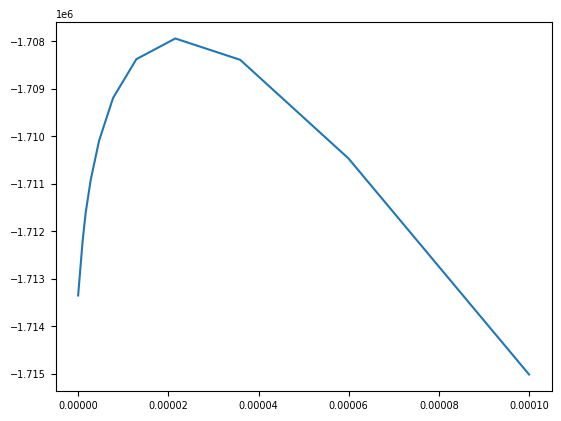

In [84]:
plt.plot(x, y)

In [59]:
def lik(params, l1, l2, l3, PY):
    
    t1 = params['t1']
    Ne1 = params['Ne1']
    Ne2 = params['Ne2']
    
    rate1 = t1 / Ne1
    rate2 = t1 / Ne2
    n1 = len(l1) - 1
    n2 = len(l2) - 1
    
    Q1 = rate_matrix(n1).toarray().T
    M1 = jax.scipy.linalg.expm(rate1 * Q1)
    l1 = M1 @ l1
    g1 = -Q1 @ l1 * t1 / Ne1 ** 2
    
    Q2 = rate_matrix(n2).toarray().T
    M2 = jax.scipy.linalg.expm(rate2 * Q2)
    l2 = M2 @ l2
    g2 = -Q2 @ l2 * t1 / Ne2 ** 2

    l4 = lemma_Split2(l1, l2)
    g1 = lemma_Split2(g1, l2)
    g2 = lemma_Split2(l1, g2)

    t2 = params['t2']
    Ne3 = params['Ne3']
    Ne4 = params['Ne4']
    
    l3 = lift(l3,  t2 / Ne3)

    l4 = lift(l4, (t2 - t1) / Ne4)
    g1 = lift(g1, (t2 - t1) / Ne4)
    g2 = lift(g2, (t2 - t1) / Ne4)
        
    l5 = lemma_Split2(l3, l4)
    g1 = lemma_Split2(l3, g1)
    g2 = lemma_Split2(l3, g2)
    
    # return l5
    
#     l5 = lift(l5, 10.)
#     g1 = lift(g1, 10.)
#     g2 = lift(g2, 10.)
    
#     l5 /= l5.sum()
#     g1 /= g1.sum()
#     g2 /= g2.sum()
    
    l = l5 @ PY
    g1 = g1 @ PY
    g2 = g2 @ PY
    
    print(g1)
    print(g2)
    
    return l

In [60]:
#plt.plot(lift(l5, 10))

In [61]:
PY = np.ones(n1 + n2 + n3 + 1)

In [62]:
params = dict(Ne1=Ne1, Ne2=Ne2, Ne3=Ne3, Ne4=Ne4, t1=t1, t2=t2)

In [63]:
lik(params, l1, l2, l3, PY)

0.0022617711
0.0017970819


Array(0.0380539, dtype=float32)

In [65]:
st = time()



1683066327.3006232

In [64]:
l, grad = jax.value_and_grad(lik)(params, l1, l2, l3, PY)
grad['Ne1']

Traced<ConcreteArray(0.0022617713548243046, dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array(0.00226177, dtype=float32)
  tangent = Traced<ShapedArray(float32[])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7fb6dc4d2510>, in_tracers=(Traced<ShapedArray(float32[25]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x7fb6dc2ad3f0; to 'JaxprTracer' at 0x7fb6dc2ad8a0>], out_avals=[ShapedArray(float32[])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[25] b:f32[25]. let
    c:f32[] = dot_general[dimension_numbers=(([0], [0]), ([], []))] a b
  in (c,) }, 'in_shardings': (<jax._src.interpreters.pxla.UnspecifiedValue object at 0x7fb77b1b77c0>, <jax._src.interpreters.pxla.UnspecifiedValue object at 0x7fb77b1b77c0>), 'out_shardings': (<jax._src.interpre

Array(0.00226178, dtype=float32, weak_type=True)